In [2]:
import xarray as xr
import os, glob

# --- Data paths --- 
NETID = "k16v981"
WBT_DIR = f"/home/{NETID}/my_work/code/arabian_peninsula/bayesian_extremes/data/DailyMax-WBT" 
WBT_GLOB = os.path.join(WBT_DIR, "DailyMax-WBT-*.nc")

# Find files
files = sorted(glob.glob(WBT_GLOB))

# Open one file
ds = xr.open_dataset(files[0])

print(ds)

ERROR 1: PROJ: proj_create_from_database: Open of /home/k16v981/.conda/envs/my_env/share/proj failed


<xarray.Dataset> Size: 3GB
Dimensions:    (longitude: 1440, latitude: 721, time: 365)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 3kB 1950-01-01 1950-01-02 ... 1950-12-31
Data variables:
    twx        (time, latitude, longitude) float64 3GB ...
Attributes:
    data:     wet bulb temperature from ERA5
    method:   NEWT
    unit:     °C


In [3]:
ds = xr.open_dataset(f"/home/{NETID}/my_work/code/arabian_peninsula/bayesian_extremes/data/WetBulbTempInputData/WetBulbTempInput-*.nc")

In [9]:
print(ds)

<xarray.Dataset> Size: 25MB
Dimensions:                 (day: 31, longitude: 121, latitude: 121)
Coordinates:
  * day                     (day) datetime64[ns] 248B 2003-12-01 ... 2003-12-31
  * longitude               (longitude) float32 484B 35.0 35.25 ... 64.75 65.0
  * latitude                (latitude) float32 484B 35.0 34.75 34.5 ... 5.25 5.0
Data variables: (12/14)
    wbt_daily_peak          (day, latitude, longitude) float32 2MB ...
    hour_of_wbt_daily_peak  (day, latitude, longitude) float32 2MB ...
    t2m_daily_peak          (day, latitude, longitude) float32 2MB ...
    hour_of_t2m_daily_peak  (day, latitude, longitude) float32 2MB ...
    t2m_at_wbt_daily_peak   (day, latitude, longitude) float32 2MB ...
    q_daily_peak            (day, latitude, longitude) float32 2MB ...
    ...                      ...
    rh_daily_peak           (day, latitude, longitude) float32 2MB ...
    hour_of_rh_daily_peak   (day, latitude, longitude) float32 2MB ...
    rh_at_wbt_daily_peak 

ERROR 1: PROJ: proj_create_from_database: Open of /home/k16v981/.conda/envs/my_env/share/proj failed


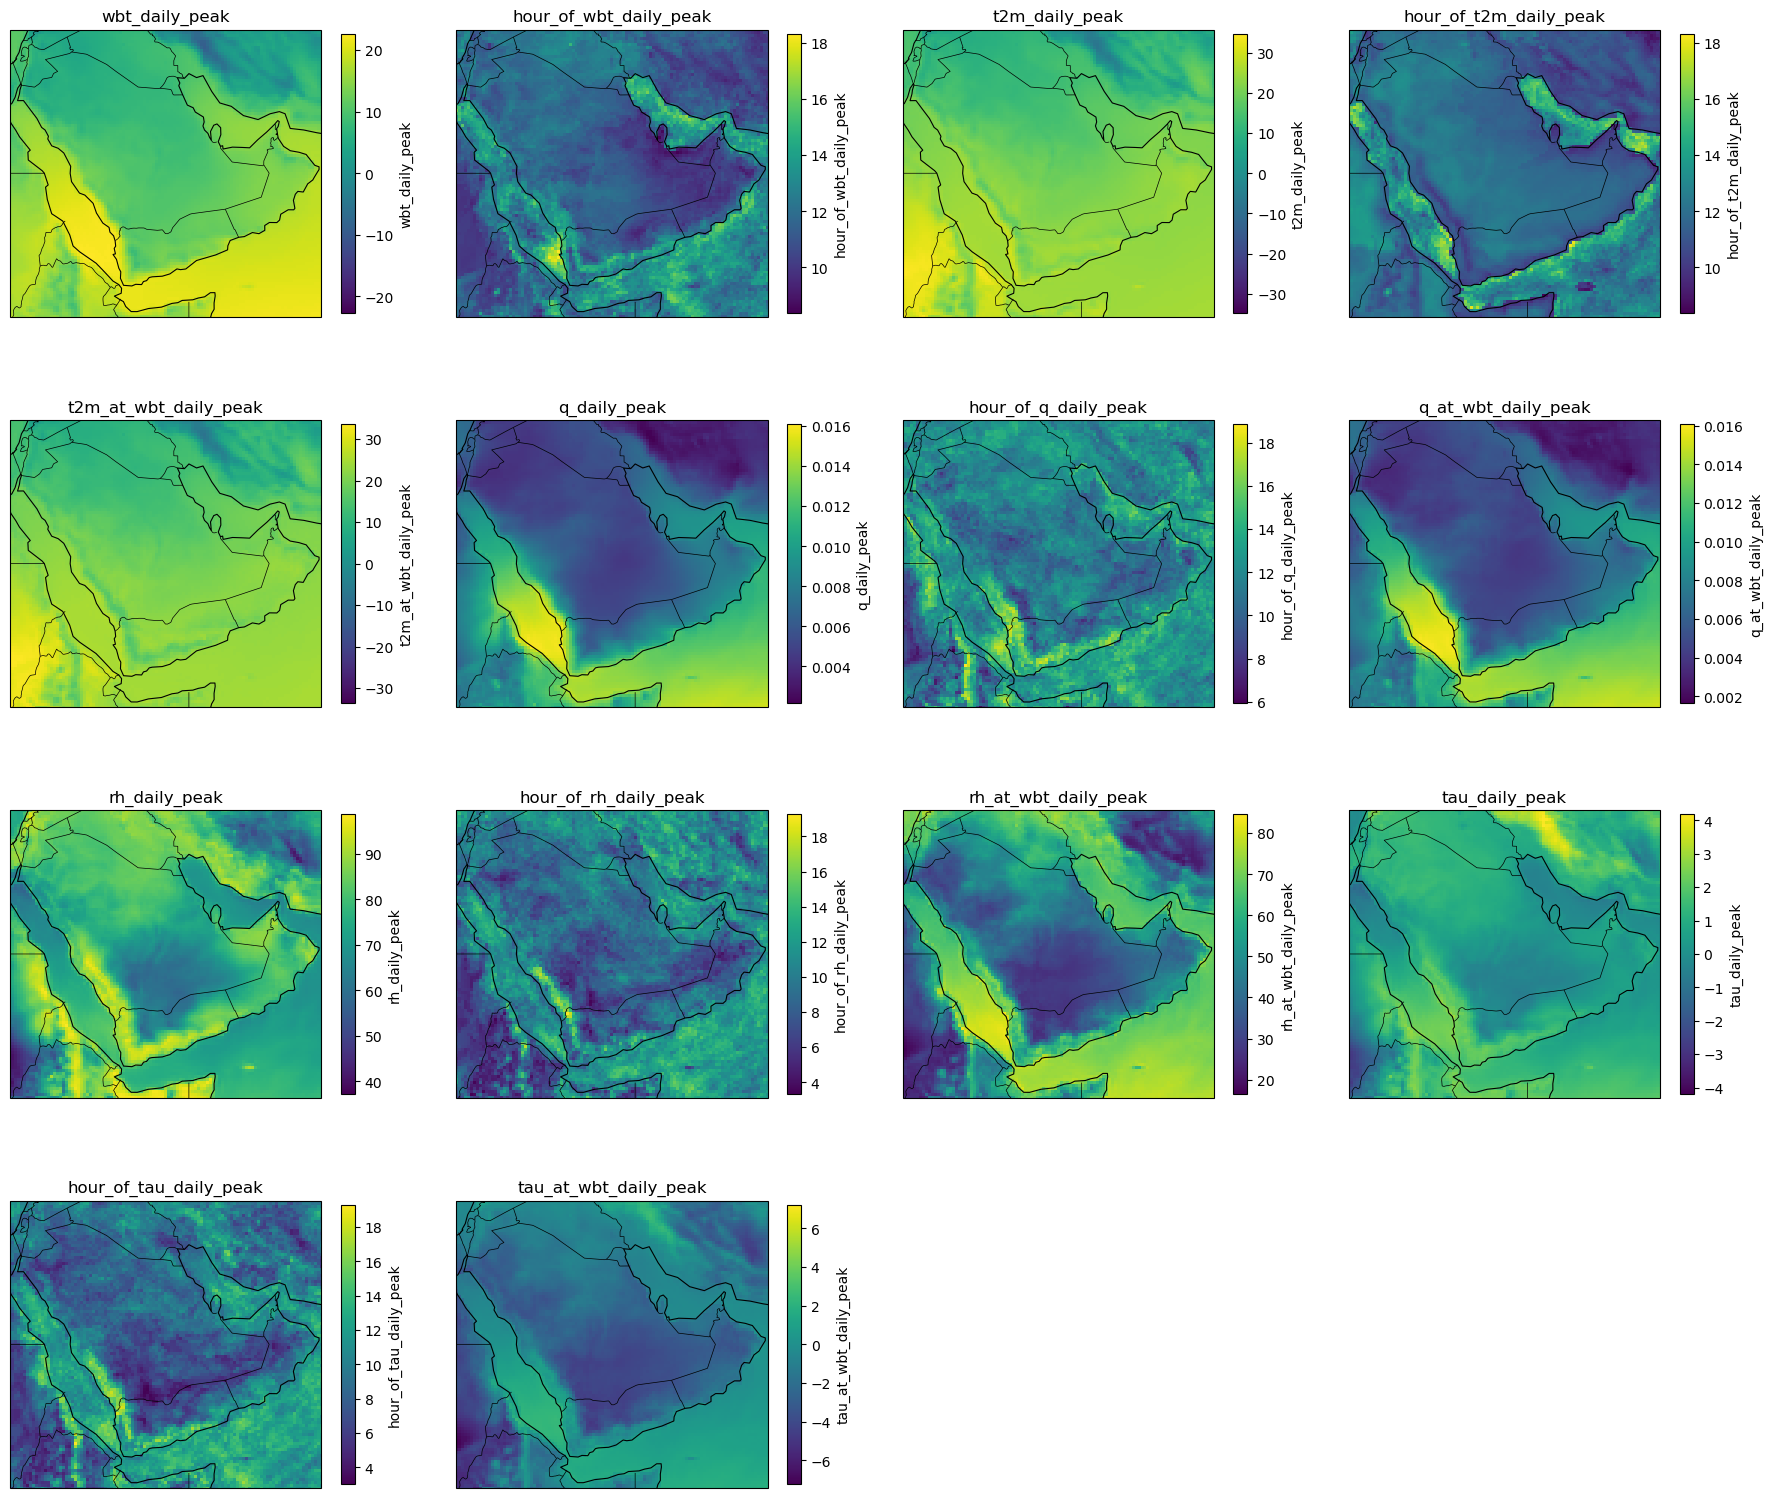

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

path = "/home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/DailyPeakState/DailyPeakState-195001.nc"

ds = xr.open_dataset(path)

# monthly means (dataset is daily)
ds_mean = ds.mean("day")

vars_to_plot = list(ds_mean.data_vars)

n = len(vars_to_plot)
cols = 4
rows = int((n + cols - 1) / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(18, 4 * rows),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):

    da = ds_mean[var]

    im = da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        add_colorbar=True,
        cbar_kwargs={"shrink":0.7},
    )

    ax.set_title(var)

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.set_extent([34, 60, 10, 34], crs=ccrs.PlateCarree())

# hide unused panels
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
import arviz as az
import numpy as np

fp = "../data/wbt_sst_city_runs/idata_city_hier_q_at_wbt_daily_peak_vs_sst_gulf_oman_JJAS.nc"

idata = az.from_netcdf(fp)

print("========= POSTERIOR SUMMARY =========")
summary = az.summary(
    idata,
    var_names=["xi","a_bar","b_bar","a_sd","b_sd"],
    round_to=3
)
display(summary)

print("\n========= CONVERGENCE CHECK =========")

max_rhat = summary["r_hat"].max()
min_ess = summary["ess_bulk"].min()

print(f"max r_hat: {max_rhat:.4f}")
print(f"min ESS  : {min_ess:.0f}")

if max_rhat < 1.01:
    print("✓ Chains appear converged (R-hat < 1.01)")
else:
    print("⚠ Possible convergence issue")

if min_ess > 400:
    print("✓ Effective sample size looks healthy")
else:
    print("⚠ ESS may be low")

print("\n========= NUTS DIAGNOSTICS =========")

ss = idata.sample_stats

if "diverging" in ss:
    n_div = int(ss["diverging"].sum())
    print("n_divergent:", n_div)

if "reached_max_treedepth" in ss:
    n_tree = int(ss["reached_max_treedepth"].sum())
    print("n_max_treedepth:", n_tree)

if "acceptance_rate" in ss:
    acc = ss["acceptance_rate"].mean().values
    print("mean acceptance_rate:", round(float(acc),3))

print("\n========= BASIC POSTERIOR CHECK =========")

print("xi mean:", float(idata.posterior["xi"].mean()))
print("xi std :", float(idata.posterior["xi"].std()))

========= POSTERIOR SUMMARY =========


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
xi,0.024,0.022,-0.016,0.066,0.000,0.000,4846.127,3831.285,1.000
a_bar,-3.925,1.385,-6.987,-1.821,0.057,0.046,628.845,380.314,1.006
b_bar,-0.287,0.140,-0.547,-0.021,0.004,0.003,1506.928,2279.667,1.001
a_sd,2.042,0.725,0.301,3.126,0.031,0.022,647.805,340.622,1.006
b_sd,0.286,0.107,0.121,0.481,0.003,0.002,1757.060,2695.045,1.001



========= CONVERGENCE CHECK =========
max r_hat: 1.0060
min ESS  : 629
✓ Chains appear converged (R-hat < 1.01)
✓ Effective sample size looks healthy

========= NUTS DIAGNOSTICS =========
n_divergent: 1
n_max_treedepth: 159
mean acceptance_rate: 0.966

========= BASIC POSTERIOR CHECK =========
xi mean: 0.023984043802747265
xi std : 0.021634861649063586


In [18]:
import os
import arviz as az

# -----------------------
# Config
# -----------------------
NETID = "k16v981"

VALID_BASINS = [
    "gulf_oman",
    "arabian_gulf",
    "red_sea",
    "gulf_aden",
]

OUT_DIR = f"/home/{NETID}/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs"

def idata_path(target_var, basin):
    return os.path.join(
        OUT_DIR,
        f"idata_city_hier_{target_var}_vs_sst_{basin}_JJAS.nc"
    )

# -----------------------
# Check files
# -----------------------
target_var = "wbt_daily_peak"

for basin in VALID_BASINS:
    ipath = idata_path(target_var, basin)

    print("\n" + "=" * 70)
    print("BASIN :", basin)
    print("FILE  :", ipath)
    print("EXISTS:", os.path.exists(ipath))

    if os.path.exists(ipath):
        print("SIZE  :", os.path.getsize(ipath), "bytes")

        try:
            idata = az.from_netcdf(ipath, engine="netcdf4")
            print("✅ opened with engine='netcdf4'")
            print("   posterior vars:", list(idata.posterior.data_vars))
            print("   sample_stats vars:", list(idata.sample_stats.data_vars))
        except Exception as e:
            print("❌ failed with engine='netcdf4':", repr(e))

            try:
                idata = az.from_netcdf(ipath)
                print("✅ opened with default engine")
                print("   posterior vars:", list(idata.posterior.data_vars))
                print("   sample_stats vars:", list(idata.sample_stats.data_vars))
            except Exception as e2:
                print("❌ failed with default engine:", repr(e2))


BASIN : gulf_oman
FILE  : /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_wbt_daily_peak_vs_sst_gulf_oman_JJAS.nc
EXISTS: True
SIZE  : 28252871 bytes
✅ opened with engine='netcdf4'
   posterior vars: ['a_bar', 'b_bar', 'a_z', 'b_z', 'xi', 'a_sd', 'b_sd', 'a_city', 'b_city', 'sigma']
   sample_stats vars: ['tree_depth', 'perf_counter_diff', 'energy', 'step_size_bar', 'largest_eigval', 'process_time_diff', 'smallest_eigval', 'index_in_trajectory', 'lp', 'perf_counter_start', 'energy_error', 'step_size', 'n_steps', 'reached_max_treedepth', 'acceptance_rate', 'diverging', 'max_energy_error']

BASIN : arabian_gulf
FILE  : /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_wbt_daily_peak_vs_sst_arabian_gulf_JJAS.nc
EXISTS: True
SIZE  : 0 bytes
❌ failed with engine='netcdf4': OSError(-51, 'NetCDF: Unknown file format')
❌ failed with default engine: OSError('Unable to open file (file signa